# 03. Feature Engineering — DataLoader

Pipeline de carga de imágenes para los 4 modelos (ResNet-50, EfficientNet-B0, ViT, Swin).

- Input nativo **128×128** RGB (sin resize)
- Normalización ImageNet
- Augmentation solo en **train**
- Fuente: manifests en `data/05_model_input/`

## 1. Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import (
    GarimpoDataset,
    IMAGENET_MEAN,
    IMAGENET_STD,
    IMAGE_SIZE,
    create_dataloaders,
    get_transforms,
    load_manifest,
)

DATA_DIR = ROOT / "data"
CHIPS_DIR = DATA_DIR / "01_raw" / "dataset_amazonia_garimpo_binario"
MODEL_INPUT = DATA_DIR / "05_model_input"

BATCH_SIZE = 32
NUM_WORKERS = 0  # en Windows/notebook usar 0; en Linux puedes subir a 2-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")

Device: cpu
Image size: 128×128


## 2. Crear DataLoaders

In [2]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

for split, loader in loaders.items():
    n = len(loader.dataset)
    batches = len(loader)
    print(f"{split:5} | {n:>6,} chips | {batches:>5,} batches (batch_size={BATCH_SIZE})")

train | 81,938 chips | 2,561 batches (batch_size=32)
val   | 14,840 chips |   464 batches (batch_size=32)
test  | 14,806 chips |   463 batches (batch_size=32)


## 3. Verificar un batch

In [3]:
images, labels = next(iter(loaders["train"]))

print(f"Tensor imágenes: {images.shape}  →  [batch, canales, H, W]")
print(f"Tensor labels:   {labels.shape}")
print(f"dtype imágenes:  {images.dtype}")
print(f"Rango píxeles:   [{images.min():.3f}, {images.max():.3f}]")
print(f"Labels batch:    {labels.tolist()[:10]}...")
print(f"Balance batch:   com_garimpo={( labels == 1).sum().item()}, sem_garimpo={(labels == 0).sum().item()}")

Tensor imágenes: torch.Size([32, 3, 128, 128])  →  [batch, canales, H, W]
Tensor labels:   torch.Size([32])
dtype imágenes:  torch.float32
Rango píxeles:   [-2.118, 2.640]
Labels batch:    [1, 1, 1, 0, 0, 1, 1, 1, 1, 1]...
Balance batch:   com_garimpo=21, sem_garimpo=11


## 4. Visualizar batch de train

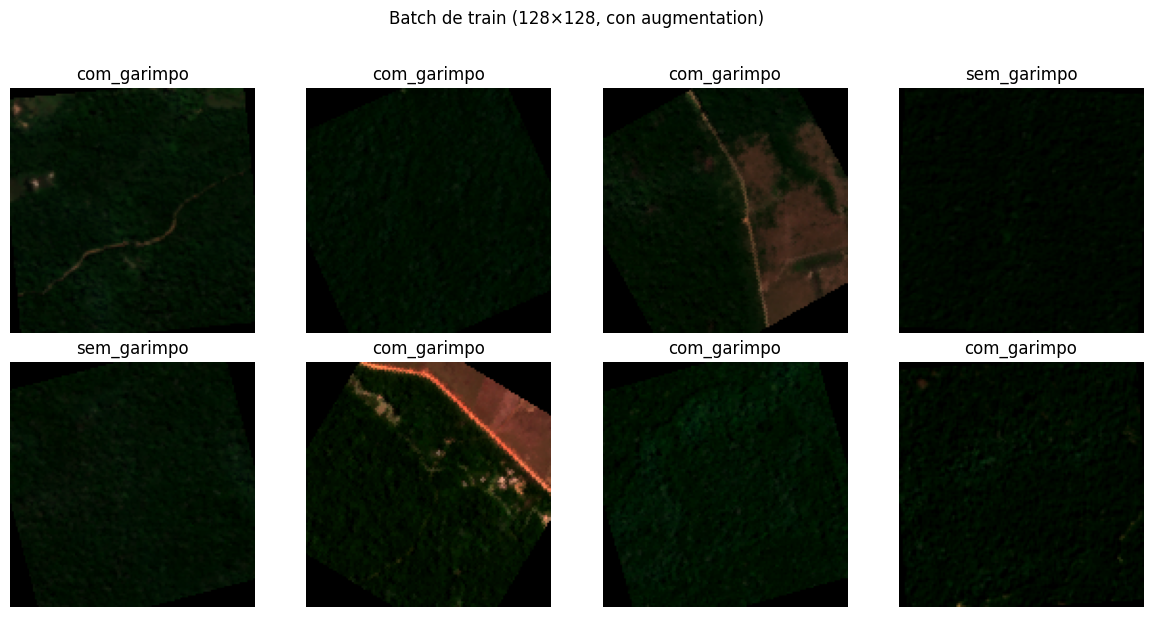

In [4]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """Convierte tensor normalizado a imagen numpy para matplotlib."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor.cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


LABEL_NAMES = {0: "sem_garimpo", 1: "com_garimpo"}

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.flat, range(8)):
    ax.imshow(denormalize(images[i]))
    ax.set_title(LABEL_NAMES[labels[i].item()])
    ax.axis("off")

plt.suptitle("Batch de train (128×128, con augmentation)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Comparar train vs val (sin vs con augmentation)

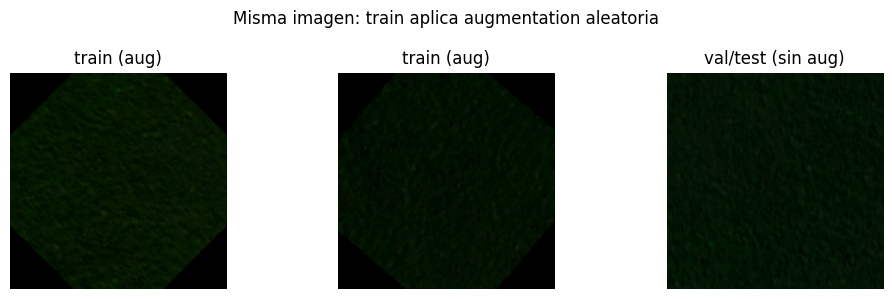

In [5]:
manifest_sample = load_manifest(MODEL_INPUT / "manifest_train.csv").head(1)

ds_train = GarimpoDataset(manifest_sample, CHIPS_DIR, get_transforms("train"))
ds_val = GarimpoDataset(manifest_sample, CHIPS_DIR, get_transforms("val"))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, _ in zip(axes, range(3)):
    img_aug, _ = ds_train[0]
    ax.imshow(denormalize(img_aug))
    ax.set_title("train (aug)")
    ax.axis("off")

img_val, _ = ds_val[0]
axes[2].imshow(denormalize(img_val))
axes[2].set_title("val/test (sin aug)")
axes[2].axis("off")

plt.suptitle("Misma imagen: train aplica augmentation aleatoria")
plt.tight_layout()
plt.show()

## 6. Sanity check — balance por split

In [6]:
for split in ("train", "val", "test"):
    manifest = load_manifest(MODEL_INPUT / f"manifest_{split}.csv")
    pct = manifest["label_str"].value_counts(normalize=True).mul(100).round(1)
    print(
        f"{split:5} | com_garimpo {pct.get('com_garimpo', 0):>5}% | "
        f"sem_garimpo {pct.get('sem_garimpo', 0):>5}% | {len(manifest):,} chips"
    )

train | com_garimpo  56.1% | sem_garimpo  43.9% | 81,938 chips
val   | com_garimpo  45.3% | sem_garimpo  54.7% | 14,840 chips
test  | com_garimpo  19.1% | sem_garimpo  80.9% | 14,806 chips


## 7. Uso en notebook 04 (modelado)

En el entrenamiento, importa los loaders igual:

```python
from src.data.dataset import create_dataloaders

loaders = create_dataloaders(data_dir=DATA_DIR, batch_size=32)
train_loader = loaders["train"]
val_loader   = loaders["val"]
test_loader  = loaders["test"]

# Modelo timm — todos aceptan 128×128, 3 canales
import timm
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)

# Para ViT/Swin a 128×128, pasa img_size=128:
# model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2, img_size=128)
```

Nombres timm para los 4 modelos:
- `resnet50`
- `efficientnet_b0`
- `vit_base_patch16_224` + `img_size=128`
- `swin_tiny_patch4_window7_224` + `img_size=128`